# Real-world Data Wrangling

## Problem Statement:

The project explores how stellar properties relate to the habitabity of exoplanets, measured by the Earth Similarity Index (ESI). The relationships can help spot habitable planets that are more likely to host life. The analysis uses three datasets, NASA exoplanets containing planet properties, NASA stellar dataset containing the stellar properties, and a dataset containing habitable exoplanets including the ESI values. Merging the three datasets, allows analysis on how stellar temperature and mass relate to Earth-like planets.  

### Research question: How do stellar properties relate to Earth-like planets that are habitable or the Earth Similarity Index (ESI)?

In [1]:
!pip install kagglehub --upgrade --quiet

In [2]:
import kagglehub
import requests
import pandas as pd
import matplotlib.pyplot as plt

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **Dataset 1**

**Type:** CSV File

**Method:** The first dataset was gathered programmatically using the KaggleHub package, which takes the set directly from Kaggle. Majority of the code is provided from the Kaggle download option, to allow the dataset to be imported automatically. The *read_csv* method calls the folder, and the actual file name to be able to read the dataset file. The dataset includes information on exoplanets.

**Variables:** 
- **name** - The name of the exoplanet.                
- **distance** - Distance of the planet from Earth in light-years.
- **planet_type** - Classification of the planet. (Gas Giant, Super-Earth, etc.)
- **orbital_radius** - Average distance of the planet from the host star.
- **orbital_period** - The time it takes for the planet to complete one orbit.

In [3]:
path = kagglehub.dataset_download("adityamishraml/nasaexoplanets")
print("Path to dataset files:", path)

100%|██████████| 114k/114k [00:00<00:00, 59.2MB/s]

Extracting files...
Path to dataset files: /home/student/.cache/kagglehub/datasets/adityamishraml/nasaexoplanets/versions/2


In [4]:
df_exoplanets = pd.read_csv(path + '/cleaned_5250.csv')

#### Dataset 2

**Type:** API

**Method:** The second dataset was gathered by using an API request from the Nasa Exoplanet Archive. The data was gathered using the requests library and following the instructions on the Nasa Archive to create the API url. In creating the url, we are able to select what columns are relevant to our analysis and include them in the query step of the url itself. Most of the url was provided on the instructions page, other than our specified columns. The JSON response from the API was then created into a pandas dataframe. The dataset inculdes stellar/star information exoplanets orbit.

**Variables:**
- **hostname** - Name of the host star that the exoplanet orbits.
- **st_spectype** - Spectral classification of the host star. (Based on surface temp. and absorption)
- **st_teff** - Temperature of the star in Kelvin.
- **st_rad** - Radius of the star relative of the sun in Solar Radius. (Multiple of Sun's radius)
- **st_mass** - Mass of the star relative to the sun in Solar Mass. (Multiple of Sun's mass) 

In [5]:
url = (
        "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query="
    "select+hostname,st_spectype,st_teff,st_rad,st_mass+from+stellarhosts&format=json"
)
    
response = requests.get(url)

df_stars = pd.DataFrame(response.json())

#### Dataset 3

**Type:** CSV File

**Methods:** The last dataset was gathered from the Habitable Worlds Catalog by Planetary Habitability Laboratory (associated with NASA). The data was manually downloaded as a CSV file, uploaded into the notebook, and read using pandas. The dataset contains information on potential habitable exoplanets.

**Variables:**
- **planet_name** - The name of the exoplanet.
- **star_name** - The name of the host star.
- **mass** - Mass of the planet relative to Earth. (Multiple of Earth's mass)
- **esi** - Earth Similarity Index, which measures how similar the planet is to Earth. (Based on several planetary factors/characteristics)

In [6]:
df_habitable_exop = pd.read_csv('hwc.csv')

## Assessing Data

In [7]:
#Visual observation of each dataframe.

print('Exoplanets:')
df_exoplanets.head()

Exoplanets:


,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


In [8]:
print('Stars:')
df_stars.head()

Stars:


,hostname,st_spectype,st_teff,st_rad,st_mass
0,Kepler-936,None,5610.0,1.171,1.034
1,Kepler-55,None,4505.0,0.658,0.645
2,Kepler-948,None,5447.0,0.917,0.928
3,Kepler-917,None,4894.0,0.550,0.800
4,Kepler-657,None,5719.0,0.860,NaN


In [9]:
print('Habitable Exoplanets:')
df_habitable_exop.head()

Habitable Exoplanets:


,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
0,OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00,-120.0,413.0,0,Mass,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
1,Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60,-3.6,4.4,0,Mass,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
2,Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10,NaN,NaN,0,M-R relationship,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
3,K2-283 b,Transit,K2,2018,2019-09-05,12.20,NaN,NaN,0,M-R relationship,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
4,Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94,NaN,NaN,0,M-R relationship,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre


### Quality Issue 1:

In [10]:
#Step 1 is to view information of each dataframe.
df_exoplanets.info()
df_stars.info()
df_habitable_exop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               5250 non-null   object 
 1   distance           5233 non-null   float64
 2   stellar_magnitude  5089 non-null   float64
 3   planet_type        5250 non-null   object 
 4   discovery_year     5250 non-null   int64  
 5   mass_multiplier    5227 non-null   float64
 6   mass_wrt           5227 non-null   object 
 7   radius_multiplier  5233 non-null   float64
 8   radius_wrt         5233 non-null   object 
 9   orbital_radius     4961 non-null   float64
 10  orbital_period     5250 non-null   float64
 11  eccentricity       5250 non-null   float64
 12  detection_method   5250 non-null   object 
dtypes: float64(7), int64(1), object(5)
memory usage: 533.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47174 entries, 0 to 47173
Data columns (total 5 columns):
 

In [11]:
#Step 2 shows how much missing/null data each set has.
print('Exoplanets:')
print(df_exoplanets.isna().sum())

print('\nStars:')
print(df_stars.isna().sum())

print('\nHabitable Exoplanets:')
print(df_habitable_exop.isna().sum())

Exoplanets:
name                   0
distance              17
stellar_magnitude    161
planet_type            0
discovery_year         0
mass_multiplier       23
mass_wrt              23
radius_multiplier     17
radius_wrt            17
orbital_radius       289
orbital_period         0
eccentricity           0
detection_method       0
dtype: int64

Stars:
hostname           0
st_spectype    43693
st_teff         8481
st_rad          9068
st_mass        18302
dtype: int64

Habitable Exoplanets:
P_NAME                    0
P_DETECTION               0
P_DISCOVERY_FACILITY      0
P_YEAR                    0
P_UPDATE                  0
                       ... 
P_HABITABLE               0
P_ESI                   241
S_CONSTELLATION           0
S_CONSTELLATION_ABR       0
S_CONSTELLATION_ENG       0
Length: 118, dtype: int64


**Issue and justification:** First, I used the *.info()* method to inspect the datatypes, columns, and non-null values. After assessing each dataframe, I noticed that several columns have fewer non-null values than the total number of entries indicating missing data. To gain better insight, I used the *.isna()* and *.sum()* methods to count the exact number of missing values for each column. The confirmed missing values show a data quality issue because missing data can lead to inaccurate analysis and unreliable conclusions.  

### Quality Issue 2:

In [12]:
#Inspecting duplicates.
print('Exoplanets:')
print(df_exoplanets.duplicated().sum())

print('\nStars:')
print(df_stars.duplicated().sum())
print(df_stars['hostname'].duplicated().sum())

print('\nHabitable Exoplanets:')
print(df_habitable_exop.duplicated().sum())

Exoplanets:
0

Stars:
12978
42133

Habitable Exoplanets:
0


**Issue and justification:** I inspected the datasets for duplicates using the *.duplicated()* method. I observed that the stars dataset contains 12,978 duplicated rows, while the other two have none. Duplicate rows are a date quality issue because it leads to inaccurate analysis such as counting the same rows/data and skewing results. Ensuring the data is unique is important for accuracy and true conclusions.

**Discovery Note:** I discovered an issue while merging the datasets, that the **hostname** of the **stars** dataframe contained duplicated values. I printed the *sum* of the duplicated values here, so I can show how many dupliactes there are and remove the duplicates in the cleaning process.

### Tidiness Issue 1:

In [13]:
#Inspecting column names.
print('Exoplanets:')
print(df_exoplanets.columns)

print('\nStars:')
print(df_stars.columns)

print('\nHabitable Exoplanets:')
print(df_habitable_exop.columns)

Exoplanets:
Index(['name', 'distance', 'stellar_magnitude', 'planet_type',
       'discovery_year', 'mass_multiplier', 'mass_wrt', 'radius_multiplier',
       'radius_wrt', 'orbital_radius', 'orbital_period', 'eccentricity',
       'detection_method'],
      dtype='object')

Stars:
Index(['hostname', 'st_spectype', 'st_teff', 'st_rad', 'st_mass'], dtype='object')

Habitable Exoplanets:
Index(['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE',
       'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT',
       'P_MASS_ORIGIN',
       ...
       'S_ABIO_ZONE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object', length=118)


**Issue and justification:** I inspected the column names for each dataset and found they are not standardized and difficult to understand. Some columns are not standardized, include insconsistent naming styles, and varying capitalization. The column names create a tidiness issue because it reduces readability and makes data analysis more difficult. The variable names need to be clean, consistent, and standardized for data analysis. The clean naming of columns will limit errors and improve readability.

### Tidiness Issue 2: 

In [14]:
#Inspecting columns of the habitable exoplanets dataset deeper.
df_habitable_exop.columns

Index(['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE',
       'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT',
       'P_MASS_ORIGIN',
       ...
       'S_ABIO_ZONE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object', length=118)

**Issue and justification:** I observed further that several columns in the habitable exoplanets dataset use different column names for the same variables as the other datasets, suchs as **name**, **P_NAME**, **hostname**, and **S_NAME**. The names cause a tidiness issue because the same data is labeled inconsistently across the datasets. Standardizing the names will also help to merge the datasets.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [15]:
#Creating copies for cleaning process.
df_exoplanets_clean = df_exoplanets.copy()
df_stars_clean = df_stars.copy()
df_habitable_exop_clean = df_habitable_exop.copy()

### **Quality Issue 1: Missing Data**

In [16]:
#Exoplanets: Select relevant columns.
df_exoplanets_clean = df_exoplanets_clean[['name', 'distance', 'planet_type', 'orbital_radius',
                                         'orbital_period']]

In [17]:
#Exoplanets: Fill in missing values.
df_exoplanets_clean = df_exoplanets_clean.fillna(
df_exoplanets_clean.mean(numeric_only=True)
)

In [18]:
#Exoplanets validation.
df_exoplanets_clean.isna().sum()

name              0
distance          0
planet_type       0
orbital_radius    0
orbital_period    0
dtype: int64

**Justification:** I identified and selected relevant variables of each dataset in the wrangling process. By removing non-relevant columns, I reduced the dataset and made the cleaning process more efficient. After selecting the relevant columns, I filled in the remaining missing values. Since, the remaining coulmns are numeric, I used the *.fillna* method with the *mean* of each column. Filling the missing data with the *mean*, ensures there is no missing data, helps preserve relevant data, and imrpoves the accuracy and usability of the data for analysis. 

In [19]:
#Stars: Remove non-relevant column.
df_stars_clean = df_stars_clean.drop(columns=['st_spectype'])

In [20]:
#Stars: Fill in misssing values.
df_stars_clean = df_stars_clean.fillna(df_stars_clean.mean(numeric_only=True))

In [21]:
#Stars validation.
df_stars_clean.isna().sum()

hostname    0
st_teff     0
st_rad      0
st_mass     0
dtype: int64

**Justification:** The **stars** dataset had large amounts of missing data, with the *st_spectype* being the most significant. I removed the *st_spectype* column because it contained significant amount of missing values, and is a categorical datatype. By removing the column I simplified the dataset and avoided any unreliable fill values to maintain accuracy of my analysis. Similarly, I used the *.fillna* method to fill the remaing numeric values using the *mean* to preserve and improve accuracy of the data for analysis.

In [22]:
# Select relevant columns.
df_habitable_exop_clean = df_habitable_exop_clean[[
    'P_NAME', 'S_NAME', 'P_MASS', 'P_ESI'
]]

In [23]:
#Habitable Exoplanets: Fill in missing values.
df_habitable_exop_clean = df_habitable_exop_clean.fillna(
    df_habitable_exop_clean.mean(numeric_only=True)
)

In [24]:
#Habitable Exoplanets validation.
df_habitable_exop_clean.isna().sum()

P_NAME    0
S_NAME    0
P_MASS    0
P_ESI     0
dtype: int64

**Justification:** Similar to the first two datasets, I used the *.fillna* method with the *mean* to ensure the dataset is complete.

### **Quality Issue 2: Duplicates**

In [25]:
#Remove all duplicates.
df_stars_clean = df_stars_clean.drop_duplicates()
df_stars_clean = df_stars_clean.drop_duplicates(subset='hostname')

In [26]:
#Validate dropped duplicates.
print('Exoplanets:')
print(df_exoplanets_clean.duplicated().sum())

print('\nStars:')
print(df_stars_clean.duplicated().sum())
print(df_stars_clean['hostname'].duplicated().sum())

print('\nHabitable Exoplanets:')
print(df_habitable_exop_clean.duplicated().sum())

Exoplanets:
0

Stars:
0
0

Habitable Exoplanets:
0


**Justification:** I identitfied duplicates in quality issue two, and observed only the **stars** dataset contained duplicates. I removed the duplicates using the *.drop_duplicates* method, then confirmed the dropped duplicates from the **stars** dataset, as well as validating that all three datasets have zero duplicates.

**Discovery Note:** I removed the duplicates in the **hostname** using the *.drop_duplicates(subset=)* method to ensure each **hostname** is unique. The method is important in the merge step, where I found the issue, because I need the **hostname** to be unique to avoid multiple matches during the merge process for accurate analysis.

### **Tidiness Issue 1: Cleaning column Names**

In [27]:
#Clean column names.
df_exoplanets_clean.columns = (
    df_exoplanets_clean.columns.str.lower().str.replace(' ', '_')
)

df_stars_clean.columns = (
    df_stars_clean.columns.str.lower().str.replace(' ', '_')
)

df_habitable_exop_clean.columns = (
    df_habitable_exop_clean.columns.str.lower().str.replace(' ', '_') 
)

In [28]:
#Validate cleaning.
print(df_exoplanets_clean.columns)
print('\n', df_stars_clean.columns)
print('\n', df_habitable_exop_clean.columns)

Index(['name', 'distance', 'planet_type', 'orbital_radius', 'orbital_period'], dtype='object')

 Index(['hostname', 'st_teff', 'st_rad', 'st_mass'], dtype='object')

 Index(['p_name', 's_name', 'p_mass', 'p_esi'], dtype='object')


**Justification:** I cleaned the column names by converting to all lowercase, replacing spaces with underscores. The cleaning improves readability, implements consistency and preparing the datasets for analysis. 

### **Tidiness Issue 2: Standardize Columns**

In [29]:
#Renaming columns.
df_stars_clean = df_stars_clean.rename(columns={'st_teff': 'st_temp', 'st_rad': 'st_radius'})

df_habitable_exop_clean = df_habitable_exop_clean.rename(
    columns = {
        'p_name': 'name',
        's_name': 'hostname',
        'p_mass': 'mass',
        'p_esi': 'esi',
    }                                                         
)

In [30]:
#Validate cleaning.
print(df_stars_clean.columns)
print('\n', df_habitable_exop_clean.columns)

Index(['hostname', 'st_temp', 'st_radius', 'st_mass'], dtype='object')

 Index(['name', 'hostname', 'mass', 'esi'], dtype='object')


**Justification:** I renamed the columns to standardize the variable names across each dataset. Renaming the columns improve consistency and allows forthe datasets to be merged for analysis.

### **Combine datasets**

In [31]:
#Step 1: Merge exoplanets with habitable exoplanets.
df_merge_exoplanets = pd.merge(
    df_exoplanets_clean, df_habitable_exop_clean,
    on = 'name',
    how = 'inner'
)

In [32]:
#Step 2: Merge planets with stars.
df_exoplanets_stars = pd.merge(
    df_merge_exoplanets, df_stars_clean,
    on = 'hostname',
    how = 'inner'
)

In [33]:
df_exoplanets_stars.head()

,name,distance,planet_type,orbital_radius,orbital_period,hostname,mass,esi,st_temp,st_radius,st_mass
0,1RXS J160929.1-210524 b,454.0,Gas Giant,330.0,6505.9,1RXS J160929.1-210524,3000.0000,0.049539,4060.000000,1.256863,0.850000
1,2M0437 b,419.0,Gas Giant,118.0,3110.6,2MASS J04372171+2651014,1271.3136,0.068691,3100.000000,0.840000,0.170000
2,2MASS J01033563-5515561 AB b,154.0,Gas Giant,84.0,1767.2,2MASS J01033563-5515561 A,4131.7900,0.257089,5437.562539,1.256863,0.190000
3,2MASS J01225093-2439505 b,110.0,Gas Giant,52.0,593.2,2MASS J01225093-2439505,7786.5000,0.078268,3309.000000,0.366450,0.353185
4,2MASS J02192210-3925225 b,131.0,Gas Giant,156.0,5878.1,2MASS J02192210-3925225,4417.8370,0.056534,3381.670000,1.256863,0.939356


**Justification:** First, I merged the cleaned exoplanets and habitable exoplanets dataframe using an inner join on the **name** column to filter all exoplanets that are habitable. Second, I merged the first merged dataframe with the clean stars dataframe, using an inner join on the **hostname**. The final dataset contains all the cleaned datasets, exoplanets, habitable exoplanets, and stars datasets.

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [34]:
#Saving raw datasets
df_exoplanets.to_csv('exoplanets_raw.csv', index=False)
df_stars.to_csv('stellar_hosts_raw', index=False)
df_habitable_exop.to_csv('habitable_worlds_raw.csv', index=False)

#Saving final merged dataset
df_exoplanets_stars.to_csv('exoplanets_stars_final_dataset.csv', index=False)
df_final = pd.read_csv('exoplanets_stars_final_dataset.csv')

In [35]:
df_final.head()

,name,distance,planet_type,orbital_radius,orbital_period,hostname,mass,esi,st_temp,st_radius,st_mass
0,1RXS J160929.1-210524 b,454.0,Gas Giant,330.0,6505.9,1RXS J160929.1-210524,3000.0000,0.049539,4060.000000,1.256863,0.850000
1,2M0437 b,419.0,Gas Giant,118.0,3110.6,2MASS J04372171+2651014,1271.3136,0.068691,3100.000000,0.840000,0.170000
2,2MASS J01033563-5515561 AB b,154.0,Gas Giant,84.0,1767.2,2MASS J01033563-5515561 A,4131.7900,0.257089,5437.562539,1.256863,0.190000
3,2MASS J01225093-2439505 b,110.0,Gas Giant,52.0,593.2,2MASS J01225093-2439505,7786.5000,0.078268,3309.000000,0.366450,0.353185
4,2MASS J02192210-3925225 b,131.0,Gas Giant,156.0,5878.1,2MASS J02192210-3925225,4417.8370,0.056534,3381.670000,1.256863,0.939356


## 5. Answer the research question

**Research question:** How do stellar properties relate to Earth-like planets that are habitable or the Earth Similarity Index (ESI)?

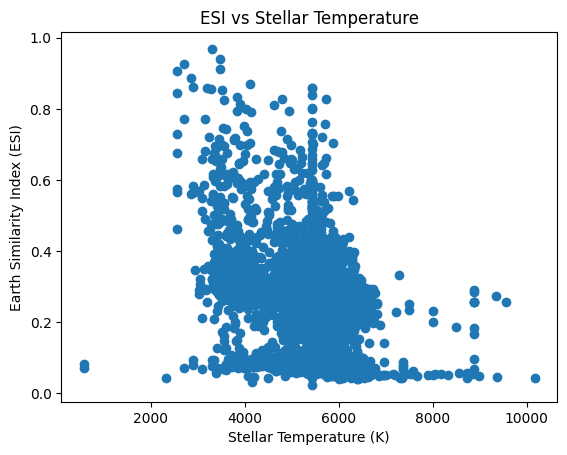

In [36]:
plt.scatter(df_final['st_temp'], df_final['esi'])
plt.xlabel('Stellar Temperature (K)')
plt.ylabel('Earth Similarity Index (ESI)')
plt.title('ESI vs Stellar Temperature')
plt.show()

**Scatterplot Analysis:** The scatterplot shows a relationship between stellar temperature and Earth Similarity Index of orbiting planets. Most of the planets are clustered between temperatures of approximately *3000K* to *6500K*, with varying range of ESI. There is no strong linear relationship between the two variables, as both high and low ESI values vary across similar temperatures. However, planets that have the largest ESI fall between *3000K* to *4000K* tapering off before temperatures reach 6000K. The higher ESI valuse at this temperature range, suggests there is a higher likelihood of finding an Earth-like/habitale planet between a host star with a temperature between *3000K* to less than 6000K. 

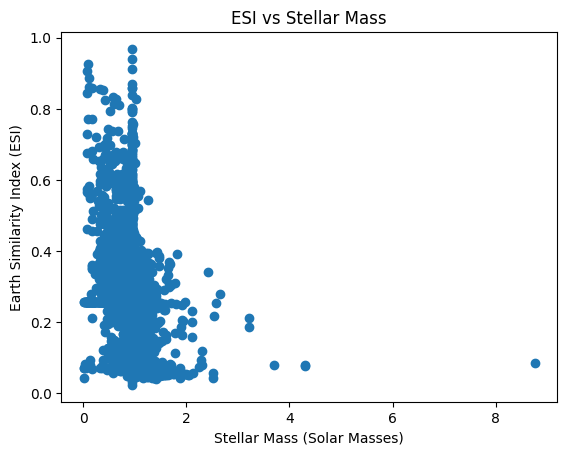

In [37]:
plt.scatter(df_final['st_mass'], df_final['esi'])
plt.xlabel('Stellar Mass (Solar Masses)')
plt.ylabel('Earth Similarity Index (ESI)')
plt.title('ESI vs Stellar Mass')
plt.show()

**Scatterplot Analysis:** The scatterplot shows the relationship between stellar mass and Earth Similarity Index of orbiting planets. Most planets are clustered around stars approximately *0.5* to *2* times the mass of our Sun. There is no strong linear relationship between the two variables, as ESI values vary across similar mass ranges. However, planets orbiting stars similar in size to our Sun tend to have a higher Earth-like Index, while planets with lower ESI tend to orbit larger massed stars. While stellar mass may influence planetary habitability, it is not a strong indicator on its own.

### **5.2:** Reflection
If I had more time to complete this project, I would further look into data quality issues of missing values, inconsistencies across other datasets, and how the planet and star properties are recorded accurately. I would want to explore more variables that impact planet habitability such as planet type, oribital distance, and stellar luminosity. Exploring other variables would help me to better understand reltionships to planet habitability. Lastly, I would want to polish the dataset by focusing on planet type, like gas vs terrestrial planets, to improve the analysis. The results may suggest that planetary properties may play a more significant role in determining ESI.  